# NLP Exercise: Word2Vec with IMDb Reviews

In this exercise, you'll process raw movie review data, clean and tokenize it, and train two types of Word2Vec models: CBOW and Skip-Gram.

Finally, you'll visualize the learned word embeddings in 2D space using PCA.

**Steps:**
1. Load the IMDb dataset
2. Perform text preprocessing:
    - Lowercasing
    - Tokenization
    - Stopword Removal
    - Stemming
    - Lemmatization
    - Remove punctuation, digits, special characters
3. Train Word2Vec models (CBOW and Skip-Gram)
4. Plot embeddings using PCA


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
import tensorflow as tf

from tensorflow.keras.datasets import imdb

In [27]:
import urllib.request
import tarfile

url='https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'
# download the data
urllib.request.urlretrieve(url,'aclImdb_v1.tar.gz')
tar=tarfile.open('aclImdb_v1.tar.gz','r:gz')
tar.extractall()
tar.close()

In [28]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [29]:
import os
from nltk.tokenize import word_tokenize

def load_imdb_data(data_dir):
    data=[]
    label=[]
    for label_type in ['neg','pos']:
        dir_name=os.path.join(data_dir,label_type)
        for name in os.listdir(dir_name):
            if name.endswith('.txt'):
              with open(os.path.join(dir_name,name),'r') as f:
                data.append(word_tokenize(f.read().lower()))
                label.append(1 if label_type=='pos' else 0)
    return data,label

In [30]:
corpus,label=load_imdb_data('aclImdb/test')

In [32]:
corpus[0]


['this',
 'one',
 'is',
 'a',
 'cut',
 'above',
 'the',
 'usual',
 'softcore',
 't',
 '&',
 'a',
 ',',
 'with',
 'the',
 'spirit',
 'of',
 'a',
 'dead',
 'actress',
 'returning',
 'to',
 'claim',
 'the',
 'film',
 'role',
 'she',
 'believes',
 'is',
 'rightfully',
 'hers',
 ',',
 'and',
 'using',
 'the',
 'body',
 'of',
 'an',
 'aspiring',
 'young',
 'actress',
 'to',
 'do',
 'so.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'as',
 'always',
 ',',
 'the',
 'gorgeously',
 'sexy',
 'amber',
 'newman',
 'the',
 'is',
 'main',
 'attraction',
 ';',
 'her',
 'sensuous',
 'presence',
 'overshadows',
 'the',
 'mildly',
 'attractive',
 ',',
 'shauna',
 "o'brien",
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'plot',
 ':',
 '*',
 '1/2',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'sex/nudity',
 ':',
 '*',
 '*',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*']

In [8]:
# ✨ Step 2: Text Cleaning & Preprocessing
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re

# Your code here
# Task: Tokenize, lowercase, remove stopwords, remove punctuation, digits, apply stemming and lemmatization

cleaned_corpus = []  # Store list of cleaned token lists for each review
# TODO: Implement text cleaning


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
# Remove Stopwords

# remove stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    # Ensure input is a list of tokens before attempting list comprehension
    if not isinstance(tokens, list):
        return [] # Or handle the non-list case as appropriate

    return [word for word in tokens if word not in stop_words]

# Iterate through the corpus and apply the remove_stopwords function
cleaned_corpus = []
for review_tokens in corpus:
    cleaned_review_tokens = remove_stopwords(review_tokens)
    cleaned_corpus.append(cleaned_review_tokens)

cleaned_corpus[0]


['one',
 'cut',
 'usual',
 'softcore',
 '&',
 ',',
 'spirit',
 'dead',
 'actress',
 'returning',
 'claim',
 'film',
 'role',
 'believes',
 'rightfully',
 ',',
 'using',
 'body',
 'aspiring',
 'young',
 'actress',
 'so.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'always',
 ',',
 'gorgeously',
 'sexy',
 'amber',
 'newman',
 'main',
 'attraction',
 ';',
 'sensuous',
 'presence',
 'overshadows',
 'mildly',
 'attractive',
 ',',
 'shauna',
 "o'brien",
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'plot',
 ':',
 '*',
 '1/2',
 '*',
 '*',
 '*',
 '*',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'sex/nudity',
 ':',
 '*',
 '*',
 '*',
 '*',
 '*',
 '*',
 '*']

In [ ]:
# remove punctuation
def remove_punctuation(tokens):
    # Ensure input is a list of tokens before attempting list comprehension
    if not isinstance(tokens, list):
        return [] # Or handle the non-list case as appropriate

    return [word for word in tokens if re.match(r'^[a-zA-Z]+$', word)]

for review_tokens in cleaned_corpus:
    cleaned_review_tokens = remove_punctuation(review_tokens)
    cleaned_corpus.append(cleaned_review_tokens)

cleaned_corpus

In [37]:
# digits
def remove_digits(tokens):
    # Ensure input is a list of tokens before attempting list comprehension
    if not isinstance(tokens, list):
        return [] # Or handle the non-list case as appropriate

    return [word for word in tokens if not re.search(r'\d', word)]

for review_tokens in cleaned_corpus:
    cleaned_review_tokens = remove_digits(review_tokens)
    cleaned_corpus.append(cleaned_review_tokens)

cleaned_corpus[0]

['this',
 'one',
 'is',
 'a',
 'cut',
 'above',
 'the',
 'usual',
 'softcore',
 't',
 '&',
 'a',
 ',',
 'with',
 'the',
 'spirit',
 'of',
 'a',
 'dead',
 'actress',
 'returning',
 'to',
 'claim',
 'the',
 'film',
 'role',
 'she',
 'believes',
 'is',
 'rightfully',
 'hers',
 ',',
 'and',
 'using',
 'the',
 'body',
 'of',
 'an',
 'aspiring',
 'young',
 'actress',
 'to',
 'do',
 'so.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'as',
 'always',
 ',',
 'the',
 'gorgeously',
 'sexy',
 'amber',
 'newman',
 'the',
 'is',
 'main',
 'attraction',
 ';',
 'her',
 'sensuous',
 'presence',
 'overshadows',
 'the',
 'mildly',
 'attractive',
 ',',
 'shauna',
 "o'brien",
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'plot',
 ':',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'sex/nudity',
 ':',
 '*',
 '*',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*']

In [12]:
# apply stemming and lemmatization
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('omw-1.4')
# Stemming
stemmer = PorterStemmer()
def apply_stemming(tokens):
    # Ensure input is a list of tokens before attempting list comprehension
    if not isinstance(tokens, list):
        return [] # Or handle the non-list case as appropriate

    return [stemmer.stem(word) for word in tokens]

    cleaned_corpus = []
for review_tokens in corpus:
    cleaned_review_tokens = apply_stemming(review_tokens)
    cleaned_corpus.append(cleaned_review_tokens)

cleaned_corpus[0]



[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


['this',
 'one',
 'is',
 'a',
 'cut',
 'above',
 'the',
 'usual',
 'softcore',
 't',
 '&',
 'a',
 ',',
 'with',
 'the',
 'spirit',
 'of',
 'a',
 'dead',
 'actress',
 'returning',
 'to',
 'claim',
 'the',
 'film',
 'role',
 'she',
 'believes',
 'is',
 'rightfully',
 'hers',
 ',',
 'and',
 'using',
 'the',
 'body',
 'of',
 'an',
 'aspiring',
 'young',
 'actress',
 'to',
 'do',
 'so.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'as',
 'always',
 ',',
 'the',
 'gorgeously',
 'sexy',
 'amber',
 'newman',
 'the',
 'is',
 'main',
 'attraction',
 ';',
 'her',
 'sensuous',
 'presence',
 'overshadows',
 'the',
 'mildly',
 'attractive',
 ',',
 'shauna',
 "o'brien",
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'plot',
 ':',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'sex/nudity',
 ':',
 '*',
 '*',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*']

In [13]:
# Lematizing
lemmatizer = WordNetLemmatizer()
def apply_lemmatization(tokens):
    # Ensure input is a list of tokens before attempting list comprehension
    if not isinstance(tokens, list):
        return [] # Or handle the non-list case as appropriate

    return [lemmatizer.lemmatize(word) for word in tokens]

cleaned_corpus = []
for review_tokens in corpus:
    cleaned_review_tokens = apply_lemmatization(review_tokens)
    cleaned_corpus.append(cleaned_review_tokens)

cleaned_corpus[0]

['this',
 'one',
 'is',
 'a',
 'cut',
 'above',
 'the',
 'usual',
 'softcore',
 't',
 '&',
 'a',
 ',',
 'with',
 'the',
 'spirit',
 'of',
 'a',
 'dead',
 'actress',
 'returning',
 'to',
 'claim',
 'the',
 'film',
 'role',
 'she',
 'belief',
 'is',
 'rightfully',
 'hers',
 ',',
 'and',
 'using',
 'the',
 'body',
 'of',
 'an',
 'aspiring',
 'young',
 'actress',
 'to',
 'do',
 'so.',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'a',
 'always',
 ',',
 'the',
 'gorgeously',
 'sexy',
 'amber',
 'newman',
 'the',
 'is',
 'main',
 'attraction',
 ';',
 'her',
 'sensuous',
 'presence',
 'overshadows',
 'the',
 'mildly',
 'attractive',
 ',',
 'shauna',
 "o'brien",
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'plot',
 ':',
 '*',
 '1/2',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*',
 '<',
 'br',
 '/',
 '>',
 '<',
 'br',
 '/',
 '>',
 'sex/nudity',
 ':',
 '*',
 '*',
 '*',
 'out',
 'of',
 '*',
 '*',
 '*',
 '*']

In [14]:
# !pip install gensim

In [15]:
#  Step 3: Train Word2Vec Models (CBOW and Skip-Gram)

from gensim.models import Word2Vec

# CBOW Model (sg=0)
cbow_model = Word2Vec(sentences=cleaned_corpus,vector_size=100,window=5,min_count=2,sg=0,epochs=5)

# Skip-Gram Model (sg=1)
skipgram=Word2Vec(sentences=cleaned_corpus,vector_size=100,window=5,min_count=2,sg=1,epochs=5)


In [16]:
commonwords=cbow_model.wv.index_to_key[:50]

In [17]:
commonwords

['the',
 ',',
 '.',
 'a',
 'and',
 'of',
 'to',
 'is',
 'it',
 '/',
 '>',
 '<',
 'br',
 'in',
 'i',
 'this',
 'that',
 "'s",
 'movie',
 'wa',
 'film',
 'with',
 'for',
 'but',
 ')',
 'you',
 '(',
 "''",
 'on',
 "n't",
 '``',
 'not',
 'are',
 'he',
 'have',
 'his',
 'one',
 'be',
 '!',
 'at',
 'they',
 'all',
 'by',
 'an',
 'who',
 'from',
 'like',
 'so',
 'there',
 'or']

In [19]:
cbow_vectors=[cbow_model.wv[word] for word in commonwords ]
skipgram_vectors=[skipgram.wv[word] for word in commonwords]

In [20]:
cbow_vectors[0]

array([ 4.08945024e-01,  3.23490113e-01,  8.02304089e-01, -2.73267448e-01,
        4.95477229e-01, -1.80787075e+00, -4.45529819e-03, -1.19300389e+00,
        1.32648933e+00, -2.93907255e-01,  1.71801066e+00, -4.43592697e-01,
       -1.03216755e+00,  6.06817424e-01, -7.63818204e-01,  7.94827491e-02,
       -1.53675878e+00, -2.25717664e+00,  6.58561289e-03, -1.02007103e+00,
       -6.16531253e-01,  1.68913054e+00,  1.27415943e+00, -3.24082106e-01,
       -1.17300129e+00,  1.99469888e+00, -1.08701277e+00,  2.27880216e+00,
       -3.30645233e-01, -3.06076676e-01, -1.20612276e+00,  1.77489340e+00,
        1.05564177e+00, -7.46488988e-01, -1.60738325e+00, -2.07975283e-01,
        5.45483172e-01, -4.72014725e-01, -2.47000241e+00,  9.07123610e-02,
       -5.01440346e-01,  1.76662898e+00, -2.29839826e+00, -1.23819768e-01,
        1.87480628e-01,  1.63709545e+00,  1.91422626e-01,  1.92885590e+00,
       -8.75729978e-01, -8.53726447e-01, -1.07731521e+00, -2.99770713e-01,
       -3.79171848e-01,  

In [21]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
cbow_2d=pca.fit_transform(cbow_vectors)
skipgram_2d=pca.fit_transform(skipgram_vectors)

In [22]:
cbow_2d[0]

array([-1.14742753, -1.08505532])

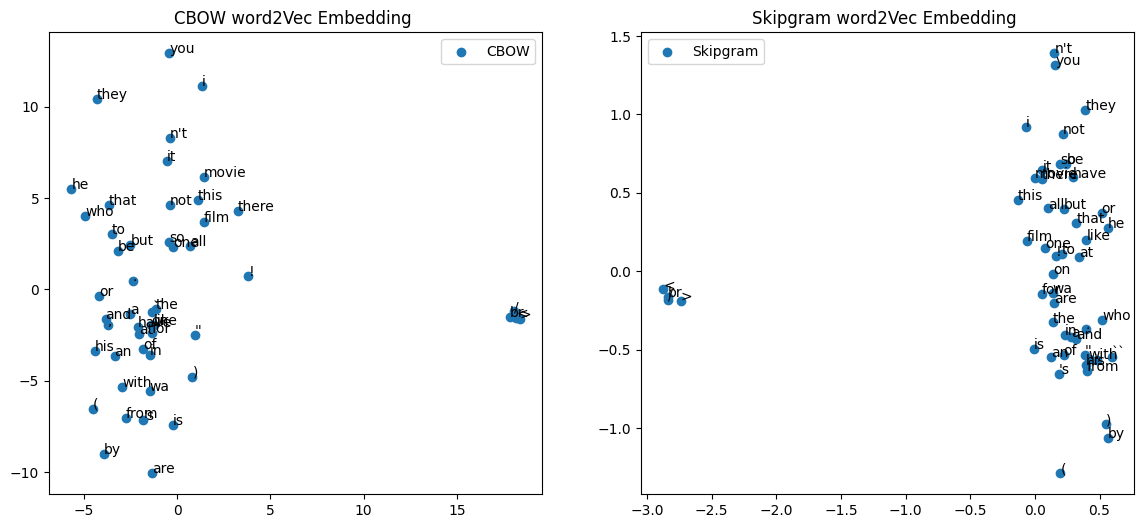

In [23]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('CBOW word2Vec Embedding ')
plt.scatter(cbow_2d[:,0],cbow_2d[:,1],label='CBOW')
for i , word in enumerate(commonwords):
  plt.annotate(word,(cbow_2d[i,0],cbow_2d[i,1]))
plt.legend()

plt.subplot(1,2,2)
plt.title('Skipgram word2Vec Embedding ')
plt.scatter(skipgram_2d[:,0],skipgram_2d[:,1],label='Skipgram')
for i , word in enumerate(commonwords):
  plt.annotate(word,(skipgram_2d[i,0],skipgram_2d[i,1]))
plt.legend()
plt.show()

In [18]:
# 📊 Step 4: Visualize Word Embeddings


